<a href="https://colab.research.google.com/github/akib-aku/Red_Sea_Shipping_Cost_Analysis/blob/main/Red_Sea_Risk_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Sea Risk Lab
Companion notebook for **"The Strait That Costs You $105"**.

Four tools: (1) Poisson table, (2) Bayesian updater, (3) regime-mixture model with a dispersion test, (4) Suez-vs-Cape cost calculator.

**Read this first.** Every number marked `ASSUMPTION` is a modelling choice, not a measured fact. Change them and see what happens. That is the point.
Sourced inputs: ~130 Houthi-*claimed* attacks (S&P Global), last recorded attack 2 Dec 2024, Suez Canal Authority urging return on 30 Jan 2025.

In [1]:
import numpy as np, math
import matplotlib.pyplot as plt
from scipy import stats

# ---------- PARAMETERS (edit me) ----------
claimed_attacks   = 130     # S&P Global, Houthi claims (not verified hits)
campaign_weeks    = 55      # approx. Nov 2023 - Dec 2024
transits_per_week = 200     # ASSUMPTION: rounded from ~30 transits/day
fleet_transits    = 30      # ASSUMPTION: one carrier, one quarter
lam = round(claimed_attacks / campaign_weeks, 1)   # rounded to 2.4 to match the video
print(f"lambda (stress case) = {lam:.2f} attacks/week")

lambda (stress case) = 2.40 attacks/week


## 1. Poisson table

P(k=0) =   9.1%
P(k=1) =  21.8%
P(k=2) =  26.1%
P(k=3) =  20.9%
P(k=4+) =  22.1%

Per-transit hit chance: 1.20%
30 transits -> expected hits 0.36, P(at least one) = 30.2%


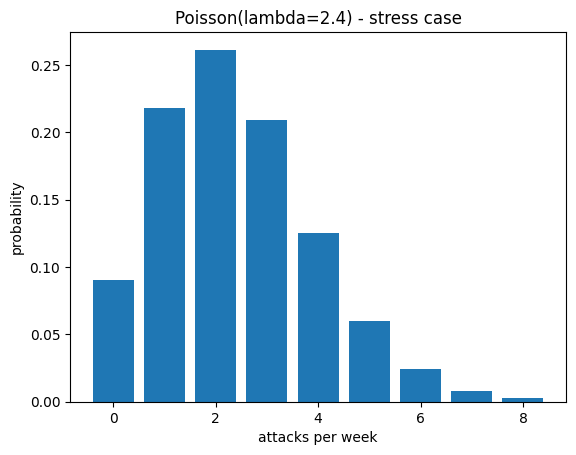

In [2]:
def poisson_table(lam, kmax=3):
    rows = [(k, stats.poisson.pmf(k, lam)) for k in range(kmax+1)]
    rows.append((f"{kmax+1}+", 1 - stats.poisson.cdf(kmax, lam)))
    return rows

for k, p in poisson_table(lam):
    print(f"P(k={k}) = {p:6.1%}")

p_transit = lam / transits_per_week
exp_hits  = fleet_transits * p_transit
print(f"\nPer-transit hit chance: {p_transit:.2%}")
print(f"{fleet_transits} transits -> expected hits {exp_hits:.2f}, P(at least one) = {1-math.exp(-exp_hits):.1%}")

ks = np.arange(0, 9)
plt.bar(ks, stats.poisson.pmf(ks, lam)); plt.xlabel("attacks per week"); plt.ylabel("probability")
plt.title(f"Poisson(lambda={lam:.1f}) - stress case"); plt.show()

## 2. Bayesian updater (prior and likelihoods are ASSUMPTIONS)

In [3]:
def bayes(prior, p_e_given_h, p_e_given_not_h):
    num = p_e_given_h * prior
    return num / (num + p_e_given_not_h * (1 - prior))

# Hypothesis H: Houthis widen the blockade from Saudi-linked ships to ALL shipping within 90 days
prior = 0.10                                   # ASSUMPTION
evidence = [("Mokha + Perim captured", 0.80, 0.30),   # ASSUMPTION likelihoods
            ("Strikes on Yanbu",       0.70, 0.50)]
p = prior
print(f"prior: {p:.1%}")
for name, ph, pnh in evidence:
    p = bayes(p, ph, pnh)
    print(f"after '{name}': {p:.1%}")
posterior = p

print("\nSensitivity to the prior (evidence treated as independent):")
for pr in [0.02, 0.05, 0.10, 0.20, 0.30]:
    q = pr
    for _, ph, pnh in evidence: q = bayes(q, ph, pnh)
    print(f"  prior {pr:4.0%} -> posterior {q:5.1%}")
print("\nCAUTION: both pieces of evidence come from the same offensive; treating them as independent double-counts.")

prior: 10.0%
after 'Mokha + Perim captured': 22.9%
after 'Strikes on Yanbu': 29.3%

Sensitivity to the prior (evidence treated as independent):
  prior   2% -> posterior  7.1%
  prior   5% -> posterior 16.4%
  prior  10% -> posterior 29.3%
  prior  20% -> posterior 48.3%
  prior  30% -> posterior 61.5%

CAUTION: both pieces of evidence come from the same offensive; treating them as independent double-counts.


In [4]:
# Optional: interactive sliders (works in Colab)
try:
    import ipywidgets as w
    from IPython.display import display
    def show(prior=0.10, l1h=0.80, l1n=0.30, l2h=0.70, l2n=0.50):
        q = bayes(bayes(prior, l1h, l1n), l2h, l2n)
        print(f"Posterior P(H) = {q:.1%}")
    w.interact(show, prior=(0.01,0.60,0.01), l1h=(0.05,0.99,0.01), l1n=(0.05,0.99,0.01),
               l2h=(0.05,0.99,0.01), l2n=(0.05,0.99,0.01))
except Exception as e:
    print("ipywidgets not available:", e)

interactive(children=(FloatSlider(value=0.1, description='prior', max=0.6, min=0.01, step=0.01), FloatSlider(v…

## 3. Regime mixture and the dispersion problem

mean 0.70, variance 1.90, dispersion index 2.70  (pure Poisson = 1.00)
P(quiet week):  Poisson 49.5%  vs mixture 73.3%
P(4+ attacks):  Poisson 0.59%  vs mixture 6.49%  (11x)


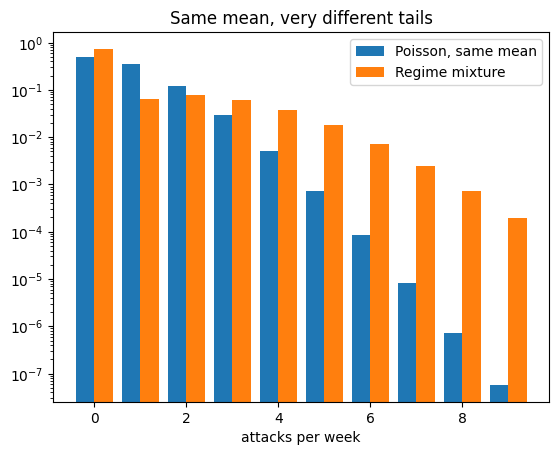

In [5]:
w_campaign = posterior            # probability we are in the campaign regime
lam_campaign, lam_quiet = lam, 0.0
mean = w_campaign*lam_campaign + (1-w_campaign)*lam_quiet
ex2  = w_campaign*(lam_campaign + lam_campaign**2)
var  = ex2 - mean**2
print(f"mean {mean:.2f}, variance {var:.2f}, dispersion index {var/mean:.2f}  (pure Poisson = 1.00)")

def mix_pmf(k):  return w_campaign*stats.poisson.pmf(k, lam_campaign) + (1-w_campaign)*(k==0)
p0_poisson, p0_mix = stats.poisson.pmf(0, mean), mix_pmf(0)
p4_poisson = 1 - stats.poisson.cdf(3, mean)
p4_mix     = w_campaign*(1 - stats.poisson.cdf(3, lam_campaign))
print(f"P(quiet week):  Poisson {p0_poisson:.1%}  vs mixture {p0_mix:.1%}")
print(f"P(4+ attacks):  Poisson {p4_poisson:.2%}  vs mixture {p4_mix:.2%}  ({p4_mix/p4_poisson:.0f}x)")

ks = np.arange(0, 10)
plt.bar(ks-0.2, stats.poisson.pmf(ks, mean), 0.4, label="Poisson, same mean")
plt.bar(ks+0.2, [mix_pmf(k) for k in ks], 0.4, label="Regime mixture")
plt.yscale("log"); plt.legend(); plt.xlabel("attacks per week"); plt.title("Same mean, very different tails"); plt.show()

## 4. Backtest: the quiet streak

In [6]:
weeks_quiet = 8.5   # 2 Dec 2024 (last recorded attack, S&P Global) -> 30 Jan 2025 (Suez Canal Authority urges return)
print(f"P(no attacks for {weeks_quiet} weeks | constant lambda={lam:.1f}) = {math.exp(-lam*weeks_quiet):.2e}")
print(f"= about 1 in {1/math.exp(-lam*weeks_quiet):,.0f}")

P(no attacks for 8.5 weeks | constant lambda=2.4) = 1.38e-09
= about 1 in 723,781,421


## 5. Suez vs Cape cost calculator

Expected loss per transit: $35,183
War-risk premium:          $700,000  (20x expected loss)
Suez total ~ $735,183  vs  Cape ~ $1,000,000 (excludes ~10 extra days of ship time)
Break-even premium: 0.96% of insured value


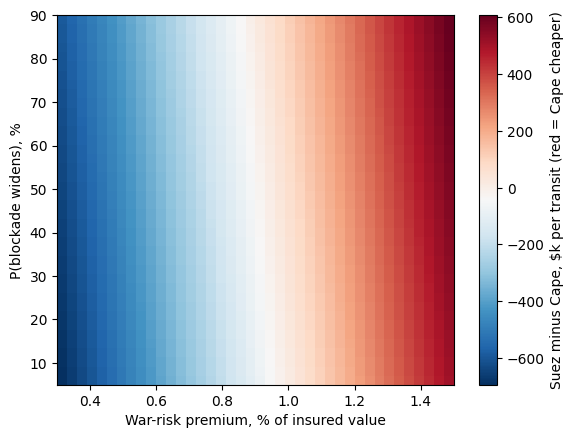

Not in this model: crew safety, a sunk or seized ship, fat-tailed severity.


In [7]:
insured_value   = 100e6    # ASSUMPTION: hull + cargo per transit
loss_per_hit    = 10e6     # ASSUMPTION: average loss per hit (mostly damage, rarely total loss)
war_risk_pct    = 0.007    # VERIFY: secondary source said 0.5-1.0%
cape_extra_cost = 1.0e6    # VERIFY: ~extra fuel per voyage (widely reported, not from this research pass)
p_hit_blend     = posterior * p_transit

exp_loss_per_transit = p_hit_blend * loss_per_hit
premium              = war_risk_pct * insured_value
suez = premium + exp_loss_per_transit
print(f"Expected loss per transit: ${exp_loss_per_transit:,.0f}")
print(f"War-risk premium:          ${premium:,.0f}  ({premium/exp_loss_per_transit:.0f}x expected loss)")
print(f"Suez total ~ ${suez:,.0f}  vs  Cape ~ ${cape_extra_cost:,.0f} (excludes ~10 extra days of ship time)")

# Break-even: how high must the premium go before Cape wins?
print(f"Break-even premium: {(cape_extra_cost-exp_loss_per_transit)/insured_value:.2%} of insured value")

# Sensitivity heatmap: premium rate vs posterior probability
pm = np.linspace(0.003, 0.015, 40); ps = np.linspace(0.05, 0.9, 40)
Z = np.array([[ (a*insured_value + b*p_transit*loss_per_hit) - cape_extra_cost for a in pm] for b in ps])
plt.imshow(Z/1e3, origin="lower", aspect="auto", extent=[pm[0]*100, pm[-1]*100, ps[0]*100, ps[-1]*100], cmap="RdBu_r")
plt.colorbar(label="Suez minus Cape, $k per transit (red = Cape cheaper)")
plt.xlabel("War-risk premium, % of insured value"); plt.ylabel("P(blockade widens), %"); plt.show()
print("Not in this model: crew safety, a sunk or seized ship, fat-tailed severity.")

## 6. Test on real data (the part that matters)
Get **weekly counts of attacks on commercial ships** from a source you trust (e.g. ACLED events, UKMTO incident reports, or IMF PortWatch disruption data), save as `weekly_attacks.csv` with columns `week,count`, and upload it here.

If no file is found, the cell uses **synthetic data labelled as such** just so you can see the method work. **Do not quote the synthetic output as a finding.**

In [8]:
import os, pandas as pd
if os.path.exists("weekly_attacks.csv"):
    df = pd.read_csv("weekly_attacks.csv"); counts = df["count"].values; label = "REAL DATA"
else:
    rng = np.random.default_rng(0)
    regime = rng.random(104) < 0.3
    counts = np.where(regime, rng.poisson(2.4, 104), 0); label = "SYNTHETIC (illustration only)"

n, m, v = len(counts), counts.mean(), counts.var(ddof=1)
D = v/m
chi2 = (n-1)*v/m                       # dispersion test statistic ~ chi2(n-1) under a true Poisson
pval = 1 - stats.chi2.cdf(chi2, n-1)
print(f"[{label}] weeks={n}, mean={m:.2f}, variance={v:.2f}, dispersion index={D:.2f}")
print(f"Chi-square dispersion test: stat={chi2:.1f}, p-value={pval:.2e}  -> {'reject Poisson' if pval<0.05 else 'cannot reject Poisson'}")

# Negative binomial fit by method of moments (needs v > m)
if v > m:
    r = m**2/(v-m); pnb = r/(r+m)
    print(f"Negative binomial fit: r={r:.2f}, p={pnb:.3f}")
    print(f"P(4+ in a week): Poisson {1-stats.poisson.cdf(3,m):.2%}  vs NegBin {1-stats.nbinom.cdf(3,r,pnb):.2%}")

[SYNTHETIC (illustration only)] weeks=104, mean=0.67, variance=2.16, dispersion index=3.21
Chi-square dispersion test: stat=331.1, p-value=0.00e+00  -> reject Poisson
Negative binomial fit: r=0.30, p=0.311
P(4+ in a week): Poisson 0.50%  vs NegBin 5.11%
